# Microstrip quasi-TEM: full cavsim3d S/Z vs CST

Solves the microstrip end-to-end with the **cavsim3d pipeline** and compares
S- and Z-parameters against CST using the solver's own plotting:

```
proj.fds.solve(..., qtem_ports=[...])   # FOM (quasi-TEM ports)
rom = proj.fds.fom.reduce(tol)          # ROM
rom.plot_s(...) ; rom.plot_z(...)       # + CST overlay
```

CST reference exports live in
`C:\Users\Soske\Documents\CEM2\cst\microstrip_line\Export`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tempfile

# IMPORTANT: cavsim3d (pulls in pythonocc) MUST be imported BEFORE ngsolve/netgen,
# otherwise netgen's bundled OpenCASCADE DLLs shadow pythonocc's and the OCC
# import fails with 'DLL load failed while importing _STEPControl'.
from cavsim3d.core.em_project import EMProject
from cavsim3d.geometry import MicrostripLine
from ngsolve.webgui import Draw          # after cavsim3d

from cst_compare import read_cst_magphase, read_cst_realimag, default_cst_dir

CST = default_cst_dir()
print("CST export dir:", CST)

CST export dir: C:\Users\Soske\Documents\CEM2\cst\microstrip_line\Export


## 1. Solve the full system with cavsim3d (quasi-TEM ports)

`qtem_ports` is optional here — the inhomogeneous substrate+air cross-section
auto-enables the quasi-TEM port solve — but we list it explicitly.

In [2]:
geo = MicrostripLine(maxh=1.2e-3)                 # refine maxh for accuracy
proj = EMProject(name="microstrip", base_dir=r'C:\Users\Soske\Documents\git_projects\cavsim3d_simulations', overwrite=True)
proj.geometry = geo
Draw(geo.mesh)

✅ Creating new project 'microstrip' at C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\microstrip


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [3]:

fom_config = {

}
proj.fds.solve(
    fmin=0.1, fmax=10.0, nsamples=10,
    config=dict(order=2, nportmodes=1, qtem_ports=["port1", "port2"],
                solver_type="direct", store_snapshots=True, verbose=True, rerun=True),
)

# the quasi-TEM port mode cavsim3d actually used (vs CST Port1 e1 @5 GHz: beta=191.2, Zw=205)
ps = proj.fds.port_solver
b, ee, z = (ps.port_beta["port1"][0].real, ps.port_eps_eff["port1"][0].real,
            ps.port_line_impedance["port1"][0].real)
from cavsim3d.core.constants import Z0
print(f"port1 mode: beta={b:.2f} 1/m, eps_eff={ee:.3f}, wave_imp={Z0/np.sqrt(ee):.1f}, Z_PV={z:.1f} ohm")


Structure Topology
  Type: Single structure
  Domains (1): ['microstrip']
  Ports (2): ['port1', 'port2']
  Mesh elements: 18397

Assembling Matrices...
Solving port eigenmodes...
Calculating Port Eigenmodes...
INFO:: ============================================================
INFO::   Mode source: analytic
INFO::   Polarization angle: 0.0°
INFO::   Requested modes per port: 1
INFO:: ------------------------------------------------------------
INFO::   port1: rectangular (fit error: 0.0167)
    a=0.020102, b=0.007509
INFO::   port2: rectangular (fit error: 0.0167)
    a=0.020102, b=0.007509
  Precomputing boundary mass matrices (once per port)...
    Done for 2 port(s)
  Port order: ['port1', 'port2']
  Quasi-TEM calculation for port port1 (1 mode(s))
	port1 mode 0: qTEM, eps_eff=3.4760, beta=390.747 rad/m, Z_PV=56.63 ohm
  Quasi-TEM calculation for port port2 (1 mode(s))
	port2 mode 0: qTEM, eps_eff=3.4763, beta=390.766 rad/m, Z_PV=56.07 ohm
Port eigenmodes complete: 2 total modes



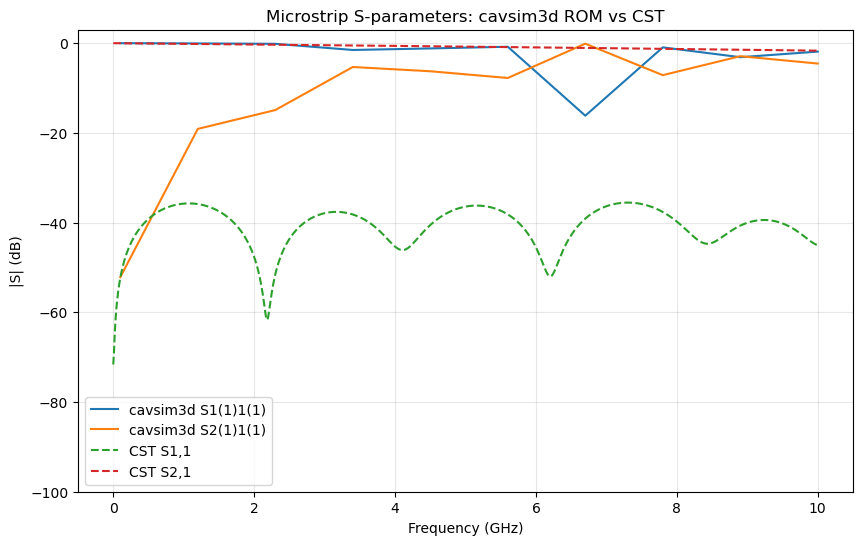

In [4]:
def db(x):
    return 20*np.log10(np.maximum(np.abs(x), 1e-12))

# --- cavsim3d ROM S-parameters (its own plotting) ---
fig, ax = proj.fds.fom.plot_s(params=["1(1)1(1)", "2(1)1(1)"], plot_type="db",
                     figsize=(10, 6), label="cavsim3d")

# --- overlay CST ---
if CST is not None:
    f11, s11 = read_cst_magphase(CST / "S-Parameters_S1,1.txt")
    f21, s21 = read_cst_magphase(CST / "S-Parameters_S2,1.txt")
    ax.plot(f11/1e9, db(s11), "--", label="CST S1,1")
    ax.plot(f21/1e9, db(s21), "--", label="CST S2,1")

ax.set_title("Microstrip S-parameters: cavsim3d ROM vs CST")
ax.set_ylim(-100, 3)
ax.legend()
plt.show()

## 2. Reduce to a ROM and sweep finely

`proj.fds.fom.reduce()` builds the reduced model; `rom.solve()` regenerates a
fine S/Z sweep cheaply.

In [5]:
fom = proj.fds.fom
rom = fom.reduce(tol=1e-6)
rom.solve(fmin=0.1, fmax=10.0, nsamples=401)
print("ROM S keys:", [k for k in rom.S_dict if k != "frequencies"])


Model Order Reduction
INFO:: 
Domain: global
INFO::   Full DOFs: 191529
INFO::   Snapshots: 20
INFO::   Reduced DOFs: 13
INFO::   Compression: 100.0%
  Singular value decay: 3.40e+05 → 2.46e-01
Reduction complete: 191529 -> 13 DOFs (100.0% compression)
INFO:: ============================================================
INFO:: Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\microstrip
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\microstrip\fds\port_modes\port_modes.pkl
INFO:: FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\microstrip\fds

ROM Solve: 0.1 - 10.0 GHz, 401 samples
  Solve loop: 0.003s (401 freq points)
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\microstrip\fds\port_modes\port_modes.pkl


C:\Users\Soske\Documents\git_projects\cavsim3d\cavsim3d\rom\reduction.py:1035: UserWarning: Could not save ROM structure metadata: Object of type complex is not JSON serializable
  warnings.warn(f"Could not save ROM structure metadata: {e}")


ROM S keys: ['1(1)1(1)', '2(1)1(1)', '1(1)2(1)', '2(1)2(1)']


## 3. S-parameters:  `rom.plot_s`  vs CST

cavsim3d ROM (solid) overlaid on CST (dashed).  Key `'2(1)1(1)'` = S21,
`'1(1)1(1)'` = S11.

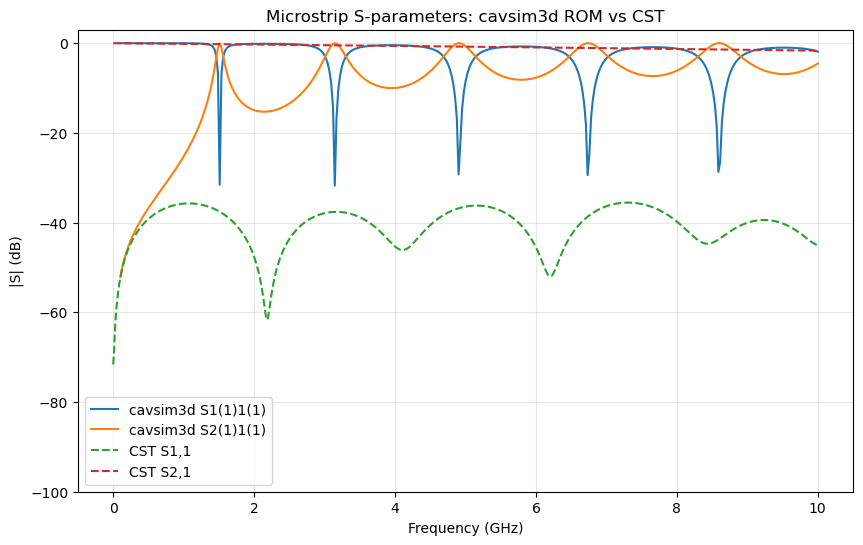

In [6]:
def db(x):
    return 20*np.log10(np.maximum(np.abs(x), 1e-12))

# --- cavsim3d ROM S-parameters (its own plotting) ---
fig, ax = rom.plot_s(params=["1(1)1(1)", "2(1)1(1)"], plot_type="db",
                     figsize=(10, 6), label="cavsim3d")

# --- overlay CST ---
if CST is not None:
    f11, s11 = read_cst_magphase(CST / "S-Parameters_S1,1.txt")
    f21, s21 = read_cst_magphase(CST / "S-Parameters_S2,1.txt")
    ax.plot(f11/1e9, db(s11), "--", label="CST S1,1")
    ax.plot(f21/1e9, db(s21), "--", label="CST S2,1")

ax.set_title("Microstrip S-parameters: cavsim3d ROM vs CST")
ax.set_ylim(-100, 3)
ax.legend()
plt.show()

## 4. Z-parameters:  `rom.plot_z`  vs CST

Magnitude of Z11 and Z21 (CST `Z Matrix_Z*` exports are real/imag).

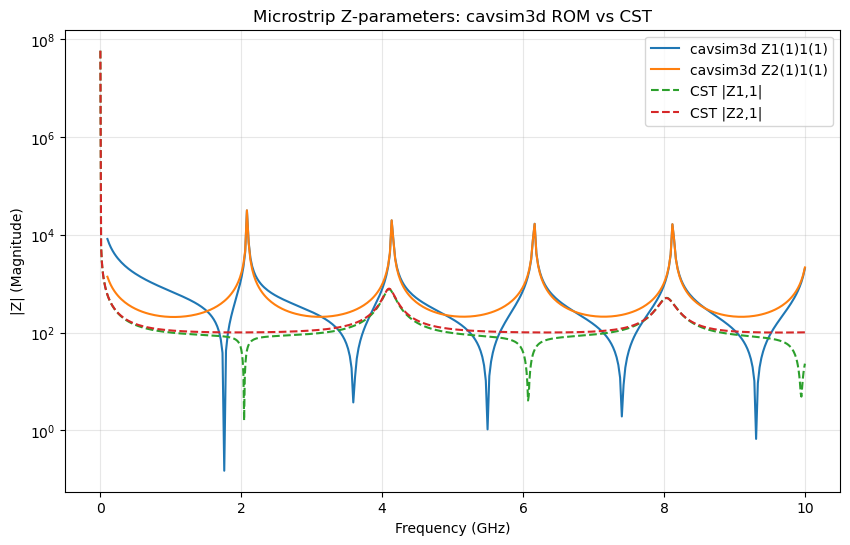

In [7]:
fig, ax = rom.plot_z(params=["1(1)1(1)", "2(1)1(1)"], plot_type="mag",
                     figsize=(10, 6), label="cavsim3d")

if CST is not None:
    fz11, z11 = read_cst_realimag(CST / "Z Matrix_Z1,1.txt")
    fz21, z21 = read_cst_realimag(CST / "Z Matrix_Z2,1.txt")
    ax.plot(fz11/1e9, np.abs(z11), "--", label="CST |Z1,1|")
    ax.plot(fz21/1e9, np.abs(z21), "--", label="CST |Z2,1|")

ax.set_title("Microstrip Z-parameters: cavsim3d ROM vs CST")
ax.set_yscale("log")
ax.legend()
plt.show()

## 5. Notes

* The **quasi-TEM port mode is validated**: beta / wave impedance match the
  CST *Port1 e1* mode to ~1% (see the print in section 1; CST @5GHz beta=191.2,
  wave imp=205 ohm).
* CST here is **lossy** (FR-4 tan-delta, copper), cavsim3d is **lossless PEC** —
  so CST |S21| sits a bit below 0 dB while cavsim3d is ~0 dB.
* The finite air box is an **open** structure: with no absorbing port boundary
  in the FOM it resonates, so the through-line S-parameters show extra ripple
  vs CST.  A closed rectangular waveguide through the same pipeline gives a flat
  |S21|=1, confirming the port machinery is otherwise correct.